In [1]:
import os
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import re
import scipy
from scipy.stats import norm, linregress, pearsonr
from scipy.optimize import Bounds, LinearConstraint, minimize, SR1

import seaborn as sns
import sys
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import display, HTML
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, roc_curve, auc
from tqdm import tqdm 
pd.set_option('display.width', 1000)


### Load in the HDT data

In [2]:
HDT = pd.read_csv('/Users/hsavage/OneDrive - University College London/Manuscripts/Staircase_HDT/07_10_revisions/Participant_data_21_02/average_merged_tasks_0503.csv', usecols = ['Participant_ID', 'HDT_overall_accuracy', 'HDT_mean_confidence'])
HDT = HDT.dropna()  # Drop rows with NaN values


### Accuracy + Confidence

In [3]:
display(HTML(HDT.to_html()))

print(HDT['HDT_overall_accuracy'].describe())

HDT_feelers = HDT[HDT['HDT_overall_accuracy'] >68]
print('\nParticipants > 68% [CHANCE]:',(len(HDT_feelers)/len(HDT['HDT_overall_accuracy']) * 100), '%; n = ',len(HDT_feelers))
HDT_feelers = HDT[HDT['HDT_overall_accuracy'] >80]
print('Participants > 80% [DETECTORS]:', (len(HDT_feelers)/len(HDT['HDT_overall_accuracy']) * 100), '%; n = ',len(HDT_feelers))

,HDT_mean_confidence,HDT_overall_accuracy,Participant_ID
0,71.50,85.00,4
1,36.00,47.50,5
2,47.00,57.50,6
3,57.25,47.50,7
4,65.00,72.50,8
5,60.38,60.00,11
6,17.68,52.50,19
7,63.25,75.00,24
8,80.50,45.00,28
9,39.50,65.00,30


count    40.000000
mean     57.209250
std      10.958636
min      37.140000
25%      47.500000
50%      56.955000
75%      65.000000
max      85.000000
Name: HDT_overall_accuracy, dtype: float64

Participants > 68% [CHANCE]: 17.5 %; n =  7
Participants > 80% [DETECTORS]: 2.5 %; n =  1


<Figure size 1000x600 with 0 Axes>

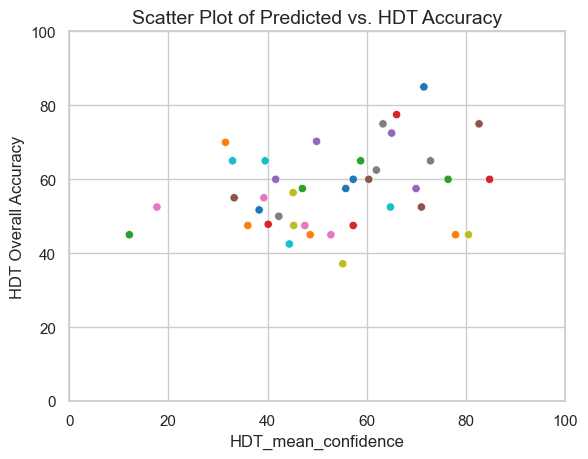

Is HDT_overall_accuracy related to HDT_mean_confidence? 
 R = 0.28897647476226124 
 P-value: 0.07052943376082799 
 R2 =  0.08350740296602381


In [4]:
# Set plot style
sns.set(style="whitegrid")

# Create scatter plot
plt.figure(figsize=(10, 6))
fig, ax = plt.subplots()
#x = np.linspace(0, 60, 100)
#ax.fill_between(x, 0, 68, color='lightgrey', alpha=0.3)
scatter = sns.scatterplot(
    data = HDT,
    x='HDT_mean_confidence', 
    y='HDT_overall_accuracy',
    hue='Participant_ID',    # Color by participant
    palette='tab10',        # Distinct colors
    alpha=1.0,  
    legend = False)# Transparency for better visibility
    #edgecolor='black'       # Black edges for clarity

# Labels & title
plt.xlim(0,100)  # Correct: Use function calls
plt.ylim(0, 100)  # Correct: Use function calls

plt.xlabel('HDT_mean_confidence', fontsize=12)
plt.ylabel('HDT Overall Accuracy', fontsize=12)
plt.title('Scatter Plot of Predicted vs. HDT Accuracy', fontsize=14)

# Adjust legend
#plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Show plot
plt.show()

HDT_pearsonR_acc_HDT_conf = pearsonr(HDT['HDT_overall_accuracy'], HDT['HDT_mean_confidence'])
print('Is HDT_overall_accuracy related to HDT_mean_confidence? \n R =', HDT_pearsonR_acc_HDT_conf[0], '\n P-value:',HDT_pearsonR_acc_HDT_conf[1], '\n R2 = ', HDT_pearsonR_acc_HDT_conf[0]**2 )


### Insight: AUROC

,HDT_mean_confidence,HDT_overall_accuracy,Participant_ID,AUC_x,AUC_y
0,71.50,85.00,4,0.544118,0.544118
1,36.00,47.50,5,0.635338,0.635338
2,47.00,57.50,6,0.530691,0.530691
3,57.25,47.50,7,0.614035,0.614035
4,65.00,72.50,8,0.722571,0.722571
5,60.38,60.00,11,0.626302,0.626302
6,17.68,52.50,19,0.395990,0.395990
7,63.25,75.00,24,0.573333,0.573333
8,80.50,45.00,28,0.488636,0.488636
9,39.50,65.00,30,0.475275,0.475275


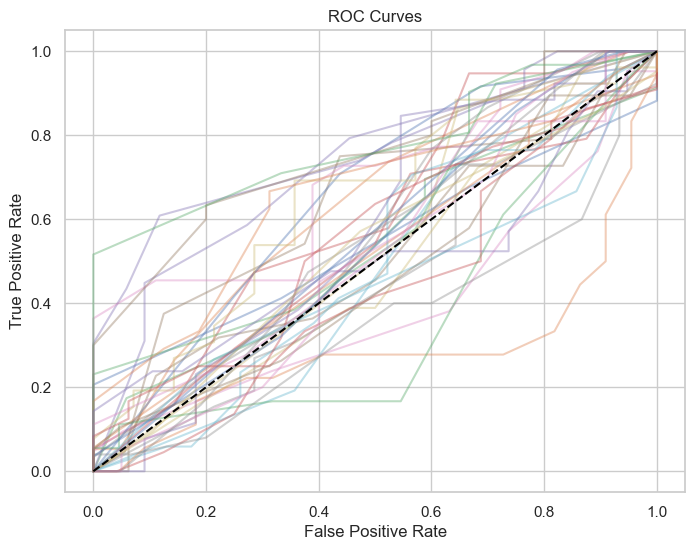

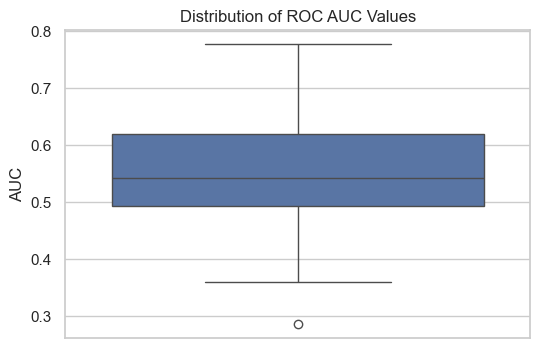

In [6]:
def calculate_auroc_hdt(participant_data, participant_id):
    # Calculate accuracy for each trial (1 = correct, 0 = incorrect)
    participant_data = participant_data.copy()
    
    # Extract test variable (confidence) and state variable (accuracy)
    y_true = participant_data['HDT_Accuracy_coded']
    y_scores = participant_data['HDT_Confidence']

    # Check for NaN values
    if y_true.isna().any() or y_scores.isna().any():
        return {'Participant': participant_id, 'roc_auc': None}
    
    # Compute ROC curve
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    
    return {'Participant': participant_id, 'fpr': fpr, 'tpr': tpr, 'roc_auc': roc_auc}

    
plt.figure(figsize=(8, 6))  # Prepare figure for group-level ROC plot


# Load trial-by-trial data
HDT_trial = pd.read_csv('/Users/hsavage/OneDrive - University College London/Manuscripts/Staircase_HDT/07_10_revisions/Participant_data_21_02/merged_tasks_trial_by_trial_0503.csv')
HDT_trial.columns = [col.strip().replace('\t', '') for col in HDT_trial.columns]

# Unique participants
participants = pd.unique(HDT_trial['ParticipantID'])
#print(HDT_trial)
#print(participants)
# Placeholder for button press counts
roc_results = []

# Iterate over each participant to count button presses
for participant in participants:
    HDT_trial_participant = HDT_trial[HDT_trial['ParticipantID'] == participant]
    if len(HDT_trial_participant) < 20:
       continue
         
         #print(HDT_trial_participant)
    #Calculate ROC
    roc_result = calculate_auroc_hdt(HDT_trial_participant, participant)
    if roc_result['roc_auc'] is None:
        #print(f"Skipping Participant {participant} due to invalid ROC AUC")
        continue  # Skip this participant if ROC is invalid
    
    roc_results.append(roc_result)

    # Plot ROC curve for each participant
    plt.plot(roc_result['fpr'], roc_result['tpr'], alpha=0.4, label=f'Participant {participant} (AUC = {roc_result["roc_auc"]:.2f})')
    #print(roc_result)


df_auc_HDT = pd.DataFrame([{'Participant_ID': r['Participant'], 'AUC': r['roc_auc']} for r in roc_results])
df_auc_HDT['Participant_ID'] = df_auc_HDT['Participant_ID'].astype(int)  # or .astype(int) if needed
HDT = pd.merge(HDT, df_auc_HDT, on = 'Participant_ID')
display(HTML(HDT.to_html()))
HDT.to_csv('/Users/hsavage/OneDrive - University College London/Manuscripts/Staircase_HDT/07_10_revisions/Real_participants_original_HDT.tsv', sep='\t', index=False)

# Finalize group-level ROC plot
plt.plot([0, 1], [0, 1], linestyle='--', color='black', alpha = 1)  # Diagonal line (random classifier)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.show()

# Create a box plot for AUC values
plt.figure(figsize=(6, 4))
sns.boxplot(y=df_auc_HDT['AUC'])
plt.title('Distribution of ROC AUC Values')
plt.ylabel('AUC')
plt.show()


### Frequency of button pressing for HDT

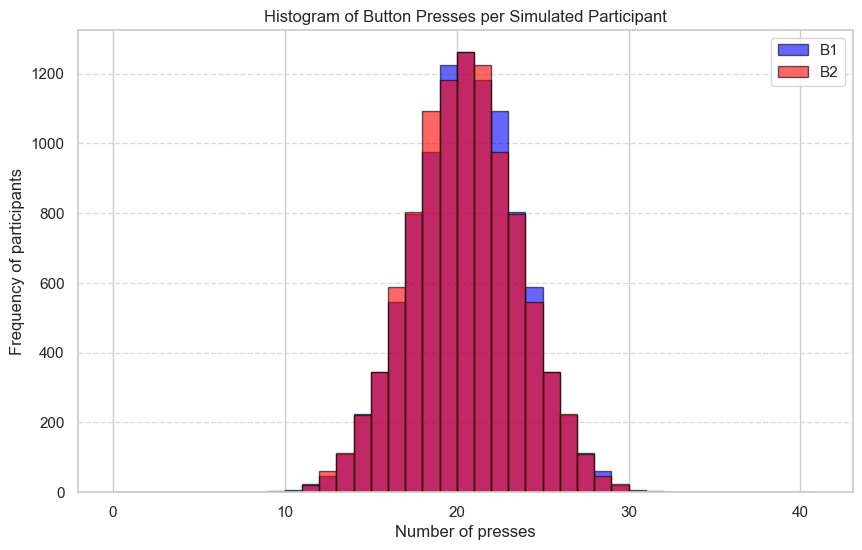

Number of participants outside cutoffs - in_sync: 1
Percentage of participants outside cutoffs - in_sync: 2.50%
Number of participants outside cutoffs - out_of_sync: 1
Percentage of participants outside cutoffs - out_of_sync: 2.50%


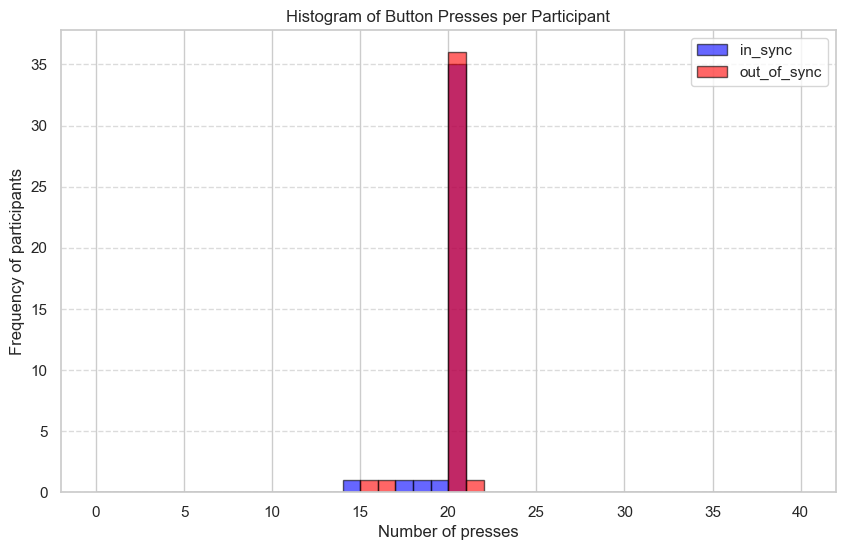

In [9]:
# Simulation parameters
num_participants = 10000
num_presses = 40

# Simulate random button presses (0 for B1, 1 for B2)
button_presses = np.random.choice([0, 1], size=(num_participants, num_presses))

# Count occurrences of B1 (0) and B2 (1) per participant
b1_counts = np.sum(button_presses == 0, axis=1)
b2_counts = np.sum(button_presses == 1, axis=1)

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(b1_counts, bins=range(0, num_presses+2), alpha=0.6, label='B1', color='blue', edgecolor='black')
plt.hist(b2_counts, bins=range(0, num_presses+2), alpha=0.6, label='B2', color='red', edgecolor='black')
plt.xlabel("Number of presses")
plt.ylabel("Frequency of participants")
plt.title("Histogram of Button Presses per Simulated Participant")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 14 (lower) and 26 (upper)


# Load data
HDT_trial = pd.read_csv('/Users/hsavage/OneDrive - University College London/Manuscripts/Staircase_HDT/07_10_revisions/Participant_data_21_02/merged_tasks_trial_by_trial_0503.csv')
HDT_trial.columns = [col.strip().replace('\t', '') for col in HDT_trial.columns]

# Unique participants
participants = pd.unique(HDT_trial['ParticipantID'])

# Placeholder for button press counts
button_press_counts = []

# Iterate over each participant to count button presses
for participant in participants:
    HDT_trial_participant = HDT_trial[HDT_trial['ParticipantID'] == participant]
    if len(HDT_trial_participant) < 20:
        continue
    
    # Count occurrences of B1 (in_sync) and B2 (out_of_sync)
    b1_count = np.sum(HDT_trial_participant['HDT_Condition'] == 'in_sync')
    b2_count = np.sum(HDT_trial_participant['HDT_Condition'] == 'out_of_sync')
    
    button_press_counts.append({'ParticipantID': participant, 'in_sync_count': b1_count, 'out_of_sync_count': b2_count})

# Convert to DataFrame
button_press_df = pd.DataFrame(button_press_counts)

# Define cutoffs
lower_cutoff, upper_cutoff = 14, 26 ## 95th% cut offs

# Count participants falling outside the cutoffs
outliers_in_sync = button_press_df[(button_press_df['in_sync_count'] < lower_cutoff) | (button_press_df['in_sync_count'] > upper_cutoff)]
outliers_out_of_sync_count = button_press_df[(button_press_df['out_of_sync_count'] < lower_cutoff) | (button_press_df['out_of_sync_count'] > upper_cutoff)]
n_outliers_in_sync = len(outliers_in_sync)
n_outliers_out_of_sync = len(outliers_out_of_sync_count)
percentage_outliers_in_sync = (n_outliers_in_sync / len(button_press_df)) * 100
percentage_outliers_out_of_sync = (n_outliers_out_of_sync / len(button_press_df)) * 100


# Print results
print(f"Number of participants outside cutoffs - in_sync: {n_outliers_in_sync}")
print(f"Percentage of participants outside cutoffs - in_sync: {percentage_outliers_in_sync:.2f}%")

print(f"Number of participants outside cutoffs - out_of_sync: {n_outliers_out_of_sync}")
print(f"Percentage of participants outside cutoffs - out_of_sync: {percentage_outliers_out_of_sync:.2f}%")


# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(button_press_df['in_sync_count'], bins=range(0, 41), alpha=0.6, label='in_sync', color='blue', edgecolor='black')
plt.hist(button_press_df['out_of_sync_count'], bins=range(0, 41), alpha=0.6, label='out_of_sync', color='red', edgecolor='black')
plt.xlabel("Number of presses")
plt.ylabel("Frequency of participants")
plt.title("Histogram of Button Presses per Participant")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


### Calculate d' c'

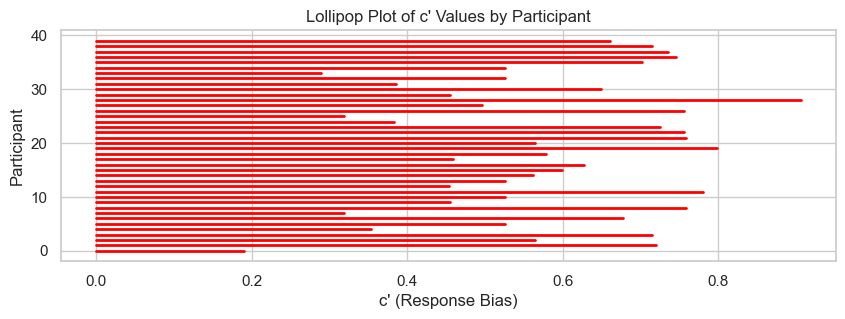

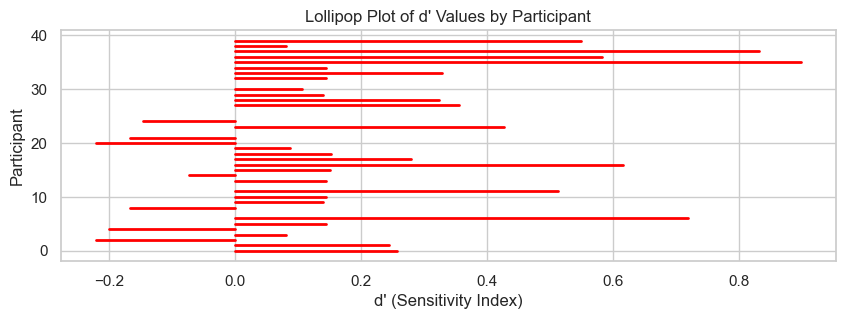

,Participant,Hits,False Alarms,Hit Rate,False Alarm Rate,d',z_H,z_F,c',P(c)
count,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000
mean,64.175000,12.875000,10.375000,0.315395,0.256698,0.184496,-0.488601,-0.673097,0.580849,0.529348
std,40.108754,3.659813,3.159743,0.064550,0.075988,0.281809,0.184575,0.246015,0.165655,0.044364
min,4.000000,8.000000,5.000000,0.200000,0.125000,-0.220728,-0.841621,-1.150349,0.190673,0.462500
25%,34.500000,10.000000,8.000000,0.268750,0.200000,0.000000,-0.616943,-0.841621,0.457365,0.500000
50%,61.500000,13.000000,10.500000,0.325000,0.253205,0.143998,-0.453762,-0.664471,0.571277,0.525000
75%,92.500000,15.000000,13.000000,0.356250,0.306250,0.325033,-0.368650,-0.506741,0.721112,0.553125
max,131.000000,28.000000,16.000000,0.475000,0.400000,0.897002,-0.062707,-0.253347,0.905565,0.637500


In [10]:
##Add other tasks:
HDT_trial = pd.read_csv('/Users/hsavage/OneDrive - University College London/Manuscripts/Staircase_HDT/07_10_revisions/Participant_data_21_02/merged_tasks_trial_by_trial_0503.csv')
#print(HDT)
HDT_trial.columns = [col.strip().replace('\t', '') for col in HDT_trial.columns]

# Placeholder for d' calculations
d_prime_results = []

participants =pd.unique(HDT_trial['ParticipantID'])
#print(participants)

# Iterate over each participant to calculate hits, misses, hit rate, and d'
for participant in participants:
    HDT_trial_participant = HDT_trial[HDT_trial['ParticipantID'] == participant]
    #print(HDT_trial_participant)
    if len(HDT_trial_participant) < 20:
        continue
    # Calculate hits: (1 and 1) or (2 and 2)
    hits = np.sum(((HDT_trial_participant['HDT_Condition'] == 'in_sync') & (HDT_trial_participant['HDT_Accuracy'] == 'correct'))) 
    
    # Calculate false alarms: (1 and 2) or (2 and 1)
    false_alarm = np.sum(((HDT_trial_participant['HDT_Condition'] == 'out_of_sync') & (HDT_trial_participant['HDT_Accuracy'] == 'correct'))) 

    total_trials = len(HDT_trial_participant)
        
    # Calculate hit rate and false alarm rate
    hit_rate = hits / total_trials
    false_alarm_rate = false_alarm / total_trials
    
    # Handle edge cases where hit_rate or false_alarm_rate is 0 or 1
    # The z-score function is undefined for values 0 and 1, so we can adjust these
    if hit_rate == 0:
        hit_rate = 1e-4  # Use a very small value instead of 0
    if hit_rate == 1:
        hit_rate = 1 - 1e-4  # Use a very small value less than 1
    if false_alarm_rate == 0:
        false_alarm_rate = 1e-4  # Use a very small value instead of 0
    if false_alarm_rate == 1:
        false_alarm_rate = 1 - 1e-4  # Use a very small value less than 1

    # Calculate d' (d prime)
    d_prime = (norm.ppf(hit_rate) - norm.ppf(false_alarm_rate))
        #High d'→ Good sensitivity (observer can distinguish well between signal and noise).
        # Low d'→ Poor sensitivity (observer struggles to distinguish signal from noise)
        # d' == 0 → No ability to distinguish (random guessing).
    
    # Calculate c' (c prime)
    z_H = norm.ppf(hit_rate)
    z_F = norm.ppf(false_alarm_rate)
    c_prime = -(z_H + z_F) / 2
            #c=0 → Unbiased criterion (equal likelihood of responding "yes" or "no").
            #c>0 → Conservative criterion (avoids false alarms but may miss real signals).
            #c<0 → Liberal criterion (tends to say "yes" more often, leading to more hits but also more false alarms).
    
    # Probability of correct response
    prob_correct = 0.5 + ((hit_rate - false_alarm_rate) / 2)
    
    # Store results
    d_prime_results.append({
        'Participant': participant,
        'Hits': hits,
        'False Alarms': false_alarm,
        'Hit Rate': hit_rate,
        'False Alarm Rate': false_alarm_rate,
        "d'": d_prime,
        "z_H": z_H,
        "z_F": z_F,
        "c'": c_prime,
        "P(c)": prob_correct
    })

# Convert results to a DataFrame for display
d_prime_df = pd.DataFrame(d_prime_results)

# Create the lollipop plot
plt.figure(figsize=(10, 3))

# Plot the lollipop plot using seaborn's stripplot to position the points and connect them with a line
#sns.stripplot(y='Participant', x="c'", data=d_prime_df, marker='o', size=8, color='green', alpha=0.7, jitter=False, hue = 'Participant', palette = 'viridis')

# Plot vertical lines for each point to create the "lollipop" effect
for i, participant in enumerate(d_prime_df['Participant']):
    plt.plot([0, d_prime_df.loc[i, "c'"]], [i, i], color='red', lw=2)

# Set labels and title
plt.title("Lollipop Plot of c' Values by Participant")
plt.xlabel("c' (Response Bias)")
plt.ylabel("Participant")

# Show the plot
plt.show()



# Create the lollipop plot
plt.figure(figsize=(10, 3))

# Plot the lollipop plot using seaborn's stripplot to position the points and connect them with a line
#sns.stripplot(y='Participant', x="c'", data=d_prime_df, marker='o', size=8, color='green', alpha=0.7, jitter=False, hue = 'Participant', palette = 'viridis')

# Plot vertical lines for each point to create the "lollipop" effect
for i, participant in enumerate(d_prime_df['Participant']):
    plt.plot([0, d_prime_df.loc[i, "d'"]], [i, i], color='red', lw=2)

# Set labels and title
plt.title("Lollipop Plot of d' Values by Participant")
plt.xlabel("d' (Sensitivity Index)")
plt.ylabel("Participant")

# Show the plot
plt.show()


d_prime_df.describe()